# Análisis, Limpieza, Localización, Modelado y Exportación

## Análisis
**Ficheros json analizados:**
> locales \
> actividades \
> licencias \
> terrazas 

**Nota:** En lugar de utilizar la librería `pandas` para la exploración y limpieza de los datos, prefiero utilizar la librería `duckdb`

**Ventajas DuckDB:** 
- SQL nativo
- Soporta consultas directas sobre ficheros externos `select...from csv|json|parquet`
- Vectoriza todas sus consultas con lo que consigue una velocidad de respuesta superior a pandas

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyproj import Transformer

#### Settings

In [2]:
pd.set_option('display.max_columns', None) 

### Volumetría:

**Definir de variables:**

In [3]:
data_dir = "../data"
data_raw_dir = f"{data_dir}/raw"
data_processed_dir = f"{data_dir}/processed"

In [4]:
ficheros_json = {
    "locales": f"{data_raw_dir}/locales202312.json",
    "actividades": f"{data_raw_dir}/actividadeconomica202312.json",
    "licencias": f"{data_raw_dir}/licencias202312.json",
    "terrazas": f"{data_raw_dir}/terrazas202312.json",
    "listings": f"{data_raw_dir}/airbnb_listings.json",
}

**Obtener numero de registros de los ficheros json. Guardarlos en una lista**

In [5]:
volumetria = []
for entidad, ruta in ficheros_json.items():
    sql_count = f"""SELECT count(1) FROM '{ruta}'"""
    resultado = duckdb.sql(sql_count).fetchone()[0] # type: ignore
    volumetria.append({
        "entidad": entidad,
        "registros": resultado
    })

**Generar gráfico de la volumetría de los ficheros json**

In [6]:
df_plot = pd.DataFrame(volumetria).sort_values(by='registros', ascending=False)

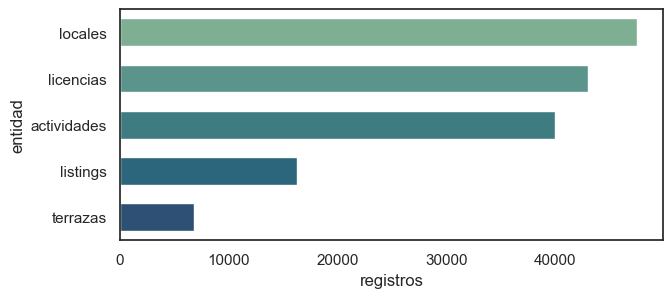

In [7]:
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(7, 3), dpi=100)
ax = sns.barplot(
    data=df_plot, 
    x='registros', 
    y='entidad', 
    hue='entidad', 
    palette='crest', 
    legend=False,
    width=0.6,
    ax=ax
)

## Limpieza

### Materializar ficheros como tablas (in memory)

In [ ]:
con = duckdb.connect()
con.execute("PRAGMA enable_profiling;")

### Schema Definitions

In [ ]:
con.execute("create schema if not exists landing")
con.execute("create schema if not exists raw")
con.execute("create schema if not exists silver")
con.execute("create schema if not exists gold")

In [10]:
landing_schema = "landing"
raw_schema = "raw"
silver_schema = "silver"    
gold_schema = "gold"

### Landing Layer

> Los archivos CSV se ingestan en DuckDB sin aplicar ningún proceso previo de limpieza; se cargan tal como están en origen.

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.locales AS SELECT * FROM read_json_auto('{data_raw_dir}/locales202312.json')")

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.actividades AS SELECT * FROM read_json_auto('{data_raw_dir}/actividadeconomica202312.json')")

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.licencias AS SELECT * FROM read_json_auto('{data_raw_dir}/licencias202312.json')")

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.terrazas AS SELECT * FROM read_json_auto('{data_raw_dir}/terrazas202312.json')")

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.listings AS SELECT * FROM read_json_auto('{data_raw_dir}/airbnb_listings.json')")

### Raw Layer

> Se quitan espacios de los campos que son string \
> Convierte vacío a NULL \
> Todos los campos se ponen a minusculas

In [16]:
def clean_table(con, origin_schema, destiny_schema, table_name):
    query = f"""
    SELECT 
        'CREATE OR REPLACE TABLE {destiny_schema}.{table_name} AS SELECT ' ||
        string_agg(
            CASE 
                WHEN data_type = 'VARCHAR' 
                THEN 'NULLIF(TRIM(' || column_name || '), '''') AS ' || lower(column_name)
                ELSE column_name || ' AS ' || lower(column_name)
            END,
            ', '
            ORDER BY ordinal_position
        )
        || ' FROM {origin_schema}.{table_name};'
    FROM information_schema.columns
    WHERE table_schema = '{origin_schema}' and table_name = '{table_name}';
    """
    
    generated_sql = con.execute(query).fetchone()[0]
    con.execute(generated_sql)

In [17]:
clean_table(con, landing_schema, raw_schema, "locales")
clean_table(con, landing_schema, raw_schema, "actividades") 
clean_table(con, landing_schema, raw_schema, "licencias") 
clean_table(con, landing_schema, raw_schema, "terrazas") 
clean_table(con, landing_schema, raw_schema, "listings") 

## Localización

> Locales y Listings. Se le ha dado importancia a la Localización, para `relacionar en MongoDB los locales con los alojamientos`. 

### Locales. Convertir UTM → WGS84

**Extraer coordenadas UTM**

In [32]:
df_locales = con.execute(f"""
SELECT 
    id_local,
    coordenada_x_local,
    coordenada_y_local
FROM {raw_schema}.locales
WHERE coordenada_x_local != 0 OR coordenada_y_local != 0
""").fetchdf()

**Transformación**

In [33]:
transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

lon, lat = transformer.transform(
    df_locales["coordenada_x_local"].values,
    df_locales["coordenada_y_local"].values
)

df_locales["longitud"] = lon
df_locales["latitud"] = lat

**Crear GeoJSON**

In [34]:
df_locales["location"] = df_locales.apply(
    lambda row: {
        "type": "Point",
        "coordinates": [row["longitud"], row["latitud"]]
    },
    axis=1
)

**Registrar en DuckDB *(en una tabla temporal)***

In [ ]:
con.register("locales_geo_tmp", df_locales)

### Silver Layer

**`Tabla` locales:**
> PK: *id_local* \
> Quitar registros incoherentes por PK -> null, 0 \
> Quitar "duplicados" por PK -> No existen \
> Añadir campo de geolocalización WGS84

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.locales AS \
            SELECT \
                src.*, \
                geo.location \
            FROM {raw_schema}.locales src \
            LEFT JOIN locales_geo_tmp geo \
            ON src.id_local = geo.id_local \
            where ifnull(src.id_local, 0) != 0 \
            qualify row_number() over (partition by src.id_local order by src.fx_carga desc) = 1")

**`Tabla` actividades:**
> PK: *id_local*, *id_epigrafe* \
> FK: *id_local* \
> Quitar Hijas sin Padres -> `id_local` en actividades que no existen en locales \
> Quitar registros incoherentes por PK -> id_epigrafe = '-1' \
> Quitar "duplicados" por PK -> No existen

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.actividades AS \
            SELECT * \
            FROM {raw_schema}.actividades src \
            where ifnull(src.id_epigrafe, '-1') != '-1' \
            and exists (select 1 from {silver_schema}.locales where src.id_local = id_local) \
            qualify row_number() over (partition by src.id_local, src.id_epigrafe order by src.fx_carga desc) = 1")

**`Tabla` licencias:**
> PK: *id_local*, *ref_licencia* \
> FK: *id_local* \
> Quitar Hijas sin Padres -> `id_local` en licencias que no existen en locales \
> Quitar registros incoherentes por PK -> ref_licencia = '-1' \
> Quitar "duplicados" por PK -> Existen 8 registros

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.licencias AS \
            SELECT * \
            FROM {raw_schema}.licencias src \
            where ifnull(src.ref_licencia, '-1') != '-1' \
            and exists (select 1 from {silver_schema}.locales where src.id_local = id_local) \
            qualify row_number() over (partition by src.id_local, src.ref_licencia order by src.fecha_dec_lic desc) = 1")

**`Tabla` terrazas:**
> PK: *id_terraza* \
> FK: *id_local* \
> Quitar Hijas sin Padres -> `id_local` en terrazas que no existen en locales \
> Quitar registros incoherentes por PK -> null, 0 \
> Quitar "duplicados" por PK -> No existen

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.terrazas AS \
            SELECT * \
            FROM {raw_schema}.terrazas src \
            where ifnull(src.id_terraza, 0) != 0 \
            and exists (select 1 from {silver_schema}.locales where src.id_local = id_local) \
            qualify row_number() over (partition by src.id_terraza order by src.fx_carga desc) = 1")

**`Tabla` listings:**
> PK: *id* \
> Quitar registros incoherentes por PK -> null, 0 \
> Corregir orden de las coordenadas: Están como [lat, lon] y en MongoDB se requiere [lon, lat]

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.listings AS \
            SELECT \
                * EXCLUDE(location), \
                struct_pack( \
                    type := 'Point', \
                    coordinates := [ \
                        location.coordinates[2], \
                        location.coordinates[1]  \
                    ] \
                ) AS location \
            FROM {raw_schema}.listings src \
            where ifnull(src.id, 0) != 0")

### Gold Layer

#### **Modelo Desnormalizado - Embebido.**
##### Dentro de Locales se embeben los otros documentos:
- Actividades
- Licencias
- Terrazas

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {gold_schema}.locales AS \
SELECT \
    l.*, \
    list(a) FILTER (WHERE a IS NOT NULL) AS actividades, \
    list(li) FILTER (WHERE li IS NOT NULL) AS licencias, \
    any_value(t) FILTER (WHERE t IS NOT NULL) AS terraza \
FROM {silver_schema}.locales l \
LEFT JOIN {silver_schema}.actividades a \
ON l.id_local = a.id_local \
LEFT JOIN {silver_schema}.licencias li \
ON l.id_local = li.id_local \
LEFT JOIN {silver_schema}.terrazas t \
ON l.id_local = t.id_local \
GROUP BY ALL \
")

## Exportar

### Generar ficheros finales para cargar en MongoDB

#### Locales

**Tomar solo el 20% de los datos (el 100% pesa más de 1GB)**

In [ ]:
con.execute(f"CREATE OR REPLACE TABLE {gold_schema}.locales_sample AS \
            SELECT * \
            FROM {gold_schema}.locales \
            WHERE location IS NOT NULL \
            USING SAMPLE 20% (bernoulli)")

**Crear fichero JSON**

In [ ]:
con.execute(f"""
COPY {gold_schema}.locales_sample
TO '{data_processed_dir}/locales_mongodb.json'
(FORMAT JSON, ARRAY TRUE);
""")

#### Listings

**Crear fichero JSON**

In [ ]:
con.execute(f"""
COPY {silver_schema}.listings
TO '{data_processed_dir}/listings_mongodb.json'
(FORMAT JSON, ARRAY TRUE);
""")